In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict

In [3]:
import numpy as np
import pandas as pd

In [4]:
from team import Selection
from simulated_annealing import simulated_annealing, metropolis_acceptance_prob, generate_exponential_annealing_schedule, generate_logarithmic_annealing_schedule

In [5]:
full_roster_df = pd.read_csv("data/2024_whalers_league_final_player_stats.csv")

In [6]:
selection_df = full_roster_df[full_roster_df.name.isin([
    "Shai Gilgeous-Alexander", 
    "Tyrese Haliburton",
    "Andrew Nembhard",
    "Markelle Fultz",
    "Jaylen Brown",
    "OG Anunoby",
    "Franz Wagner",
    "Pat Connaughton",
    "Kristaps Porziņģis",
    "Chet Holmgren"
])]
my_sel = Selection(selection_df, full_roster_df)

cheap_selection_df = full_roster_df[full_roster_df.name.isin([
    "Doug McDermott",
    "Caleb Houstan",
    "Matt Ryan",
    "Marcus Morris",
    "Ben Sheppard",
    "A.J. Green",
    "Max Christie",
    "Alec Burks",
    "Goga Bitadze",
    "Jaxson Hayes"
])]
cheap_sel = Selection(cheap_selection_df, full_roster_df)

k = 120
y_best: -5.88
y_current: -5.88


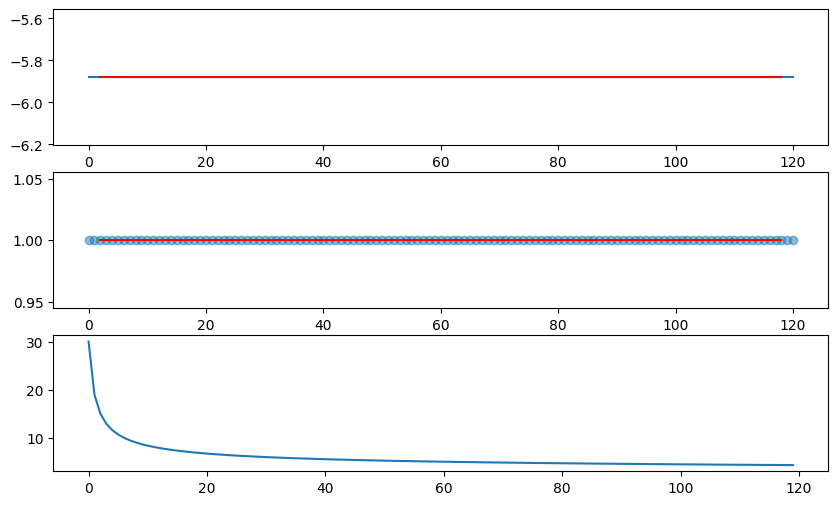

522
522
522


KeyboardInterrupt: 

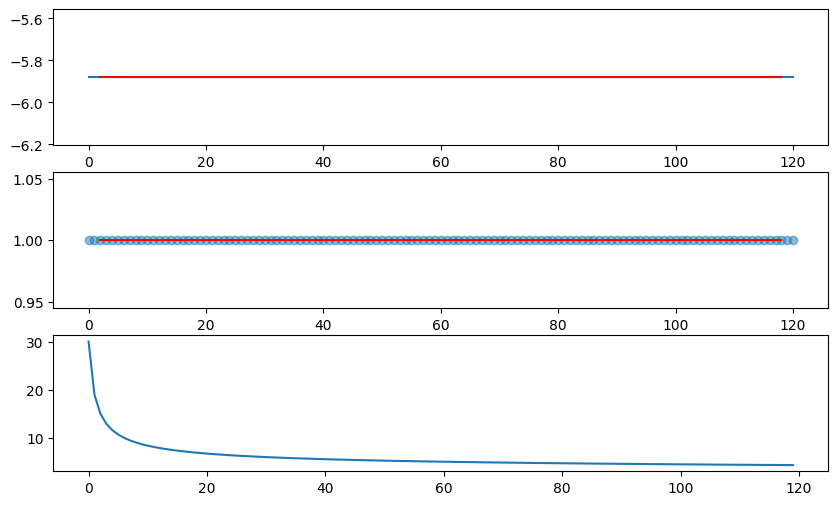

In [ ]:
def f(x: Selection) -> float:
    return -x.total_fp()*(0.01)

def team_with_swap(team, swap):
    team.swap_players(swap)
    return team

seen_teams = defaultdict(int)
possible_teams = None
def T(x: Selection) -> Selection:
    global seen_teams
    global possible_teams
    x = x.copy()
    swaps = x.possible_swaps()
    if possible_teams == None:
        possible_teams = set([team_with_swap(x.copy(), swap) for swap in swaps])
    
    new_x = sorted(list(possible_teams), key = lambda x: -seen_teams[x])[0]
    return new_x

t = generate_logarithmic_annealing_schedule(30)

opt_sel = simulated_annealing(f, cheap_sel, T, t, int(5e6), plot_interval=10, avg_interval=4)

In [7]:
print(sel.total_dv())
print(sel.total_fp())
sel.possible_swaps()

99.79999999999998
3939.5
[('Shai Gilgeous-Alexander', 'Luka Dončić'), ('Shai Gilgeous-Alexander', 'Jamal Murray'), ('Shai Gilgeous-Alexander', 'Damian Lillard'), ('Shai Gilgeous-Alexander', 'Kyrie Irving'), ('Shai Gilgeous-Alexander', 'Tyrese Maxey'), ('Shai Gilgeous-Alexander', 'Devin Booker'), ('Shai Gilgeous-Alexander', 'James Harden'), ('Shai Gilgeous-Alexander', 'Anthony Edwards'), ('Shai Gilgeous-Alexander', 'Jalen Brunson'), ('Shai Gilgeous-Alexander', 'Donovan Mitchell'), ('Shai Gilgeous-Alexander', 'Bradley Beal'), ('Shai Gilgeous-Alexander', 'Josh Giddey'), ('Shai Gilgeous-Alexander', 'Russell Westbrook'), ('Shai Gilgeous-Alexander', "D'Angelo Russell"), ('Shai Gilgeous-Alexander', 'Mike Conley'), ('Shai Gilgeous-Alexander', 'Austin Reaves'), ('Shai Gilgeous-Alexander', "De'Anthony Melton"), ('Shai Gilgeous-Alexander', 'Kentavious Caldwell-Pope'), ('Shai Gilgeous-Alexander', 'Tyler Herro'), ('Shai Gilgeous-Alexander', 'Darius Garland'), ('Shai Gilgeous-Alexander', 'Grayson Al

[('Shai Gilgeous-Alexander', 'Luka Dončić'),
 ('Shai Gilgeous-Alexander', 'Jamal Murray'),
 ('Shai Gilgeous-Alexander', 'Damian Lillard'),
 ('Shai Gilgeous-Alexander', 'Kyrie Irving'),
 ('Shai Gilgeous-Alexander', 'Tyrese Maxey'),
 ('Shai Gilgeous-Alexander', 'Devin Booker'),
 ('Shai Gilgeous-Alexander', 'James Harden'),
 ('Shai Gilgeous-Alexander', 'Anthony Edwards'),
 ('Shai Gilgeous-Alexander', 'Jalen Brunson'),
 ('Shai Gilgeous-Alexander', 'Donovan Mitchell'),
 ('Shai Gilgeous-Alexander', 'Bradley Beal'),
 ('Shai Gilgeous-Alexander', 'Josh Giddey'),
 ('Shai Gilgeous-Alexander', 'Russell Westbrook'),
 ('Shai Gilgeous-Alexander', "D'Angelo Russell"),
 ('Shai Gilgeous-Alexander', 'Mike Conley'),
 ('Shai Gilgeous-Alexander', 'Austin Reaves'),
 ('Shai Gilgeous-Alexander', "De'Anthony Melton"),
 ('Shai Gilgeous-Alexander', 'Kentavious Caldwell-Pope'),
 ('Shai Gilgeous-Alexander', 'Tyler Herro'),
 ('Shai Gilgeous-Alexander', 'Darius Garland'),
 ('Shai Gilgeous-Alexander', 'Grayson Allen')

In [18]:
sel2 = sel.swap_players(('Markelle Fultz', 'Anthony Black'))

      id           name position team    dv    fp
174  210  Anthony Black        G  ORL  1.89  15.5
      id                     name position team     dv      fp
5      6  Shai Gilgeous-Alexander        G  OKC  18.27  594.50
6      7             Jaylen Brown        F  BOS  17.36  803.75
7      8       Kristaps Porziņģis        C  BOS  16.80  182.75
26    26            Chet Holmgren        C  OKC  12.39  369.00
55    56        Tyrese Haliburton        G  IND   8.71  705.25
67    69               OG Anunoby        F  NYK   7.76  268.50
96   103             Franz Wagner        F  ORL   6.01  292.00
108  120          Pat Connaughton        F  MIL   5.31  102.25
144  167          Andrew Nembhard        G  IND   3.80  534.50
155  182           Markelle Fultz        G  ORL   3.39   87.00


In [19]:
print(sel2)

      id                     name position team     dv      fp
5      6  Shai Gilgeous-Alexander        G  OKC  18.27  594.50
6      7             Jaylen Brown        F  BOS  17.36  803.75
7      8       Kristaps Porziņģis        C  BOS  16.80  182.75
26    26            Chet Holmgren        C  OKC  12.39  369.00
55    56        Tyrese Haliburton        G  IND   8.71  705.25
67    69               OG Anunoby        F  NYK   7.76  268.50
96   103             Franz Wagner        F  ORL   6.01  292.00
108  120          Pat Connaughton        F  MIL   5.31  102.25
144  167          Andrew Nembhard        G  IND   3.80  534.50
174  210            Anthony Black        G  ORL   1.89   15.50
